In [1]:
from one.api import ONE
from pathlib import Path
import yaml
import os
import wfield
import numpy as np
import pandas as pd
from prior_localization.prepare_data import prepare_widefield
from brainbox.io.one import SessionLoader
from brainwidemap.bwm_loading import load_trials_and_mask
from prior_localization.functions.utils import compute_mask
from ibl_info.prepare_data_pid import get_new_cinc_intervals
import seaborn as sns
from matplotlib import pyplot as plt
import pickle as pkl

In [2]:
one = ONE()
sessions = one.search(datasets="widefieldU.images.npy")
print(f"{len(sessions)} sessions with widefield data found")

50 sessions with widefield data found


In [ ]:
eid = "0b7ee1b6-42db-46cd-a465-08f531366187"

In [3]:
from tqdm import tqdm

### Random old tests

In [ ]:
hemisphere = ("left", "right")
align_event = "stimOn_times"
min_rt = 0.08
max_rt = None
frame_window = (0, 2)  # this is unnecessary; should be 2 to 0 imo


def check_config():
    """Load config yaml and perform some basic checks"""
    # Get config
    with open(Path(os.getcwd()).parent.joinpath("config.yaml"), "r") as config_yml:
        config = yaml.safe_load(config_yml)
    return config


config = check_config()

# we can pass the proper align times :)
session_id = sessions[0]
sl = SessionLoader(one, eid=session_id)
sl.load_trials()
trials_mask = compute_mask(
    sl.trials, align_event="stimOn_times", min_rt=0.08, max_rt=None, n_trials_crop_end=1
)
trials = sl.trials[trials_mask]
_, target_variable, congruent_flags, incongruent_flags = get_new_cinc_intervals(trials, "stim")

  0%|          | 0/50 [00:00<?, ?it/s]

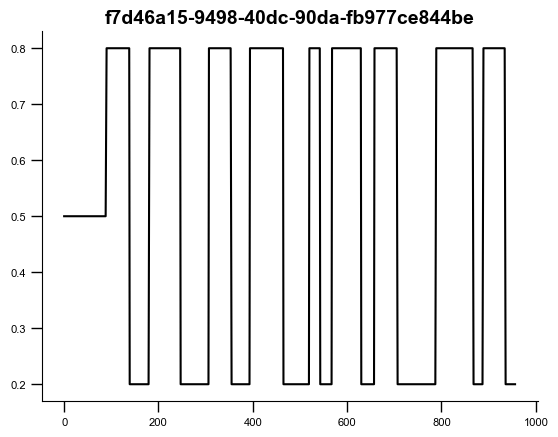

  0%|          | 0/50 [00:00<?, ?it/s]


In [6]:
for session_id in tqdm(sessions):
    sl = SessionLoader(one, eid=session_id)
    sl.load_trials()
    trials_mask = compute_mask(
        sl.trials, align_event="stimOn_times", min_rt=0.08, max_rt=None, n_trials_crop_end=1
    )
    trials = sl.trials[trials_mask]
    plt.plot(trials["probabilityLeft"])
    plt.title(f"{session_id}")
    plt.show()
    break

In [9]:
align_times = trials.stimOn_times.values

In [7]:
significant_regions = [
    ["MOs"],
    ["SSp-ul"],
    ["VISam"],
    ["VISl"],
    ["VISp"],
    ["ACAd"],
    ["PL"],
    ["RSPv"],
    ["VISa"],
]

In [10]:
data_epoch, actual_regions = prepare_widefield(
    one,
    session_id,
    hemisphere,
    regions=significant_regions,
    align_times=align_times,
    frame_window=frame_window,
    functional_channel=470,
    stage_only=False,
)

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:117: RuntimeWarning: divide by zero encountered in matmul
  res = (nM @ xy).T
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:117: RuntimeWarning: overflow encountered in matmul
  res = (nM @ xy).T
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:117: RuntimeWarning: invalid value encountered in matmul
  res = (nM @ xy).T
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:404: RuntimeWarning: divide by zero encountered in matmul
  t = self.Uflat[idx,:]@self.SVT
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:404: RuntimeWarning: overflow encountered in matmul
  t = self.Uflat[idx,:]@self.SVT
/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/wfield/utils.py:404: RuntimeWarning: invalid value encountered in matmul
  t = self.Uflat[idx,:]@self.SVT


np.False_

In [16]:
# this should load up the regions
# then we get a frame for each region
# discretize and then for each voxel in a region
# do inter and intra region pid
# also correlation because why not;
# should be super quick
# figure out how to get trial information
# do MI and pid
# figure out the flow

In [17]:
MIN_UNITS = 5

In [22]:
# do some quick checks, don't include regions with  less than 5 voxels
regions_to_keep = np.zeros(len(actual_regions))
for idx in range(len(actual_regions)):
    if data_epoch[idx].shape[-1] > MIN_UNITS:
        regions_to_keep[idx] = 1

In [25]:
regions_to_keep = np.asarray(regions_to_keep, dtype=np.bool)

In [26]:
data_to_keep = np.where(regions_to_keep == 1)

In [27]:
regions_used = np.asarray(actual_regions)[regions_to_keep]

In [28]:
from itertools import combinations

In [29]:
data_epoch[0].shape

(777, 5, 155)

In [30]:
combinations_regions = []
for x in combinations(range(len(regions_used)), 2):
    combinations_regions.append([x[0], x[1]])

combinations_regions = np.asarray(combinations_regions)

In [35]:
# now what
# for each pair of region
# okay we also first discretize
# so that we minimize io

from ibl_info.utils import discretize


discretized_data_epoch = []

for idx in range(len(regions_to_keep)):

    flag = regions_to_keep[idx]
    if flag == False:
        continue

    # i transpose this into frames x neurons x trials
    region_data = data_epoch[idx].transpose(1, 2, 0)

    discretized_region_data = np.zeros_like(region_data)
    for frame in range(discretized_region_data.shape[0]):
        discretized_region_data[frame, :] = discretize(region_data[frame, :], n_bins=3)

    discretized_data_epoch.append(discretized_region_data)

In [31]:
for region_pairs in combinations_regions:
    print(region_pairs[0], region_pairs[1])
    break

0 1


In [36]:
# now what
# for each idx in combination regions:

region_a = combinations_regions[0][0]
region_b = combinations_regions[0][1]
frame = 3

In [37]:
region_a_data = discretized_data_epoch[region_a][4, :]
region_b_data = discretized_data_epoch[region_b][4, :]

In [38]:
n1 = region_a_data.shape[0]
n2 = region_b_data.shape[0]
region_a_data.shape

(155, 777)

In [39]:
import ibl_info.measures.information_measures as info
from tqdm import tqdm

In [40]:
# there must be a better way to iterate through this

mi_region_a = np.zeros((n1))
mi_region_b = np.zeros((n2))
tvmi_array = np.zeros((n1 * n2))
pid_array = np.zeros((n1 * n2, 4))

idx = 0
for neurona in range(n1):
    mi_neurona = info.corrected_mutual_information(
        target=target_variable, source=region_a_data[neurona, :]
    )
    mi_region_a[neurona] = mi_neurona  # type: ignore
    for neuronb in range(n2):
        mi_neuronb = info.corrected_mutual_information(
            target=target_variable, source=region_a_data[neuronb, :]
        )
        mi_region_b[neuronb] = mi_neuronb  # type: ignore

        tvmi = info.corrected_tvmi(
            source_a=region_a_data[neurona, :],
            source_b=region_b_data[neuronb, :],
            target=target_variable,
        )
        pid = info.corrected_pid(
            sourcea=region_a_data[neurona, :],
            sourceb=region_b_data[neuronb, :],
            target=target_variable,
        )

        tvmi_array[idx] = tvmi  # type: ignore
        pid_array[idx, :] = pid  # type: ignore

        idx = idx + 1

In [43]:
np.mean(pid_array, axis=0), np.std(pid_array, axis=0)

(array([4.66627405e-05, 3.30664161e-04, 2.35455922e-03, 1.28928336e-03]),
 array([0.00241241, 0.00249324, 0.00234998, 0.00430826]))

### Load pid data

In [4]:
with open("../data/generated/wfi/1efa20cb-e3e9-4a28-b4f0-779e14a67d47_wfi_3bins.pkl", "rb") as f:
    data = pkl.load(f)

In [5]:
data.keys()

dict_keys([0, 1, 2])

In [32]:
np.mean(data[2]["('VISp', 'VISa')"]["incongruent"]["pid"], axis=0)

array([-0.00355186,  0.00099885, -0.00349257, -0.01698917])

In [15]:
np.mean(data[1]["('MOs', 'SSp-ul')"]["incongruent"]["pid"], axis=0)

array([-0.00081563, -0.0055673 , -0.00604146, -0.01264656])

In [16]:
np.mean(data[2]["('MOs', 'SSp-ul')"]["incongruent"]["pid"], axis=0)

array([-0.00160285, -0.00200113, -0.00383851, -0.01759361])